# TP3 - Arquitectura VGG16

# Carga y Preprocesamiento de imágenes

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/My Drive')

In [ ]:
!unzip 'landscapes_dataset.zip' -d '/content/drive/My Drive/'

In [ ]:
import tensorflow as tf
import numpy as np

# Definir el directorio del dataset
dataset_dir = '/content/drive/My Drive/landscapes_dataset/'  # Ajusta la ruta según corresponda

# Función para cargar un conjunto de datos desde un subdirectorio
def load_dataset(subdir):
    return tf.keras.preprocessing.image_dataset_from_directory(
        dataset_dir + subdir,
        labels='inferred',
        label_mode='int',  # Etiquetas como enteros
        image_size=(150, 150),  # Tamaño al que se redimensionarán las imágenes
        batch_size=32  # Tamaño de los lotes
    )

# Cargar los datasets de entrenamiento, validación y prueba
train_ds = load_dataset('train')
valid_ds = load_dataset('valid')
test_ds = load_dataset('test')

# Función para convertir un dataset de TensorFlow a arrays de Numpy
def dataset_to_numpy(dataset):
    data = []
    labels = []
    for images, labels_batch in dataset:
        data.extend(images.numpy())
        labels.extend(labels_batch.numpy())
    return np.array(data), np.array(labels)

# Convertir los datasets a Numpy arrays
train_data, train_labels = dataset_to_numpy(train_ds)
valid_data, valid_labels = dataset_to_numpy(valid_ds)
test_data, test_labels = dataset_to_numpy(test_ds)

print('Training data shape : ', train_data.shape, train_labels.shape)
print('Validation data shape : ', valid_data.shape, valid_labels.shape)
print('Test data shape : ', test_data.shape, test_labels.shape)

In [ ]:
# Reshape
train_data = train_data.reshape(-1, 150, 150, 3)

test_data = test_data.reshape(-1, 150, 150, 3)

valid_data = valid_data.reshape(-1, 150, 150, 3)

train_data.shape, test_data.shape, valid_data.shape

In [ ]:
# Contar las etiquetas de cada clase en el conjunto de entrenamiento
unique_train, counts_train = np.unique(train_labels, return_counts=True)
train_label_counts = dict(zip(unique_train, counts_train))

# Contar las etiquetas de cada clase en el conjunto de prueba
unique_test, counts_test = np.unique(test_labels, return_counts=True)
test_label_counts = dict(zip(unique_test, counts_test))

# Contar las etiquetas de cada clase en el conjunto de prueba
unique_test, counts_test = np.unique(valid_labels, return_counts=True)
valid_label_counts = dict(zip(unique_test, counts_test))

# Imprimir el conteo de cada clase
print('Training set label counts:', train_label_counts)
print('Test set label counts:', test_label_counts)
print('Test set label counts:', valid_label_counts)

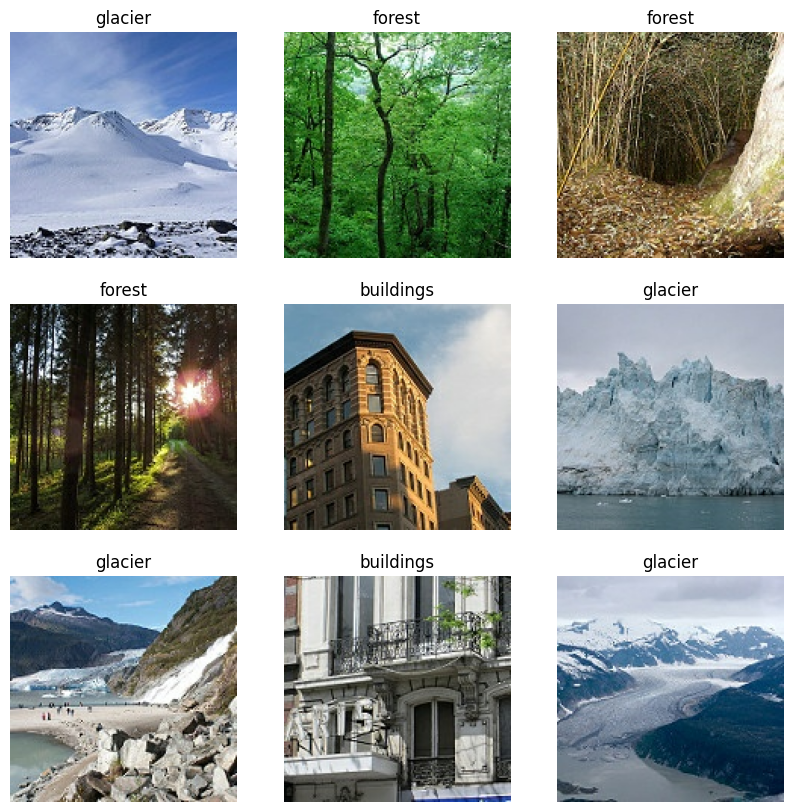

In [7]:
import matplotlib.pyplot as plt
def show_images(images, labels, class_names, num_images=9):
    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.show()

# Obtener los nombres de las clases
class_names = train_ds.class_names

# Mostrar algunas imágenes del conjunto de entrenamiento con sus etiquetas
show_images(train_data, train_labels, class_names)

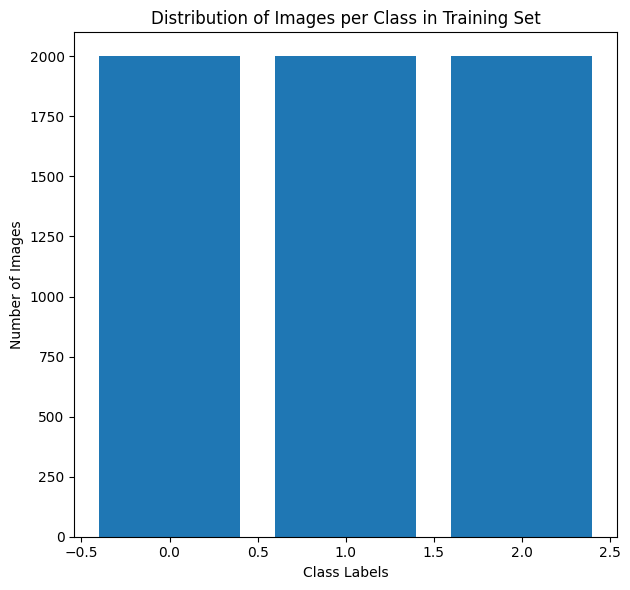

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(train_label_counts.keys(), train_label_counts.values())
plt.xlabel('Class Labels')
plt.ylabel('Number of Images')
plt.title('Distribution of Images per Class in Training Set')

plt.tight_layout()
plt.show()

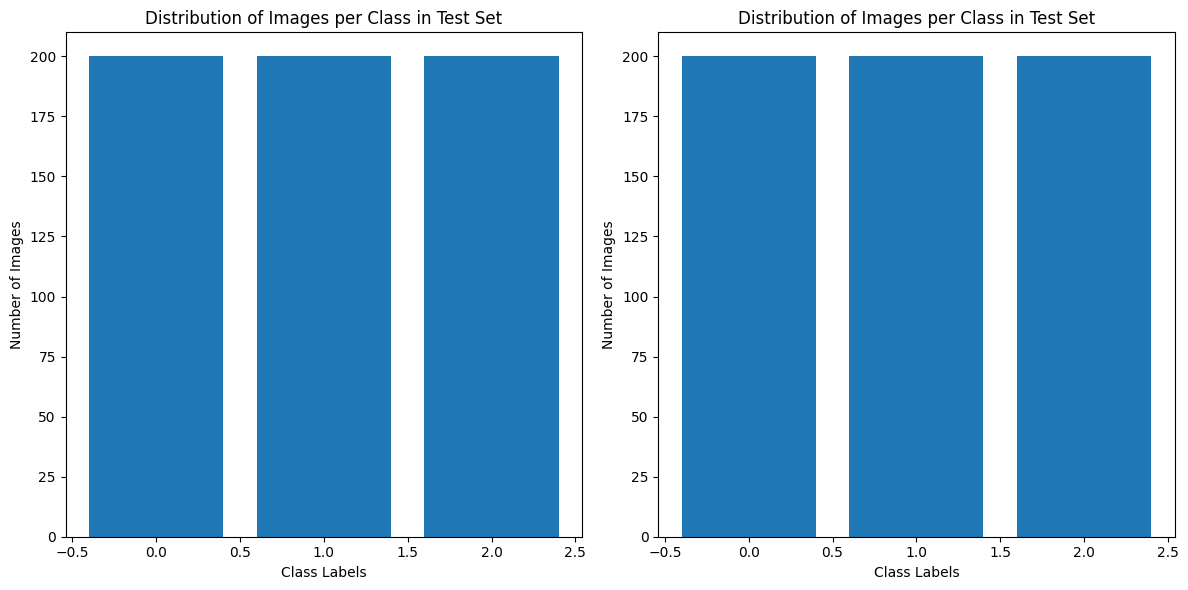

In [9]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(test_label_counts.keys(), test_label_counts.values())
plt.xlabel('Class Labels')
plt.ylabel('Number of Images')
plt.title('Distribution of Images per Class in Test Set')

plt.subplot(1, 2, 2)
plt.bar(valid_label_counts.keys(), valid_label_counts.values())
plt.xlabel('Class Labels')
plt.ylabel('Number of Images')
plt.title('Distribution of Images per Class in Test Set')

plt.tight_layout()
plt.show()

In [ ]:
from keras.utils import to_categorical
size = (200, 200)

train_X = tf.image.resize(train_data, (224, 224))
test_X = tf.image.resize(test_data, (224, 224))
valid_X = tf.image.resize(valid_data, (224, 224))

train_Y = to_categorical(train_labels, num_classes=3)
test_Y = to_categorical(test_labels, num_classes=3)
valid_Y = to_categorical(valid_labels, num_classes=3)

print(train_X.shape)
print(train_Y.shape)
print(test_X.shape)
print(test_Y.shape)
print(valid_X.shape)
print(valid_Y.shape)

# Mostrar la imagen 0
print('Original label (train):', train_labels[0])
print('After conversion to one-hot:', train_Y[0])
print('Original label (test):', test_labels[0])
print('After conversion to one-hot:', test_Y[0])
print('Original label (valid):', valid_labels[0])
print('After conversion to one-hot:', valid_Y[0])

# Modelo VGG16

In [11]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

train_X = preprocess_input(train_X)
test_X = preprocess_input(test_X)

base_model = VGG16(weights="imagenet", include_top=False, input_shape=train_X[0].shape)
base_model.trainable = False


58889256/58889256 [==============================] - 0s 0us/step


In [12]:
base_model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [13]:
# Agregar capas de clasificación

from tensorflow.keras import layers, models
num_clases = 3

flatten_layer = layers.Flatten()
dense_layer_1 = layers.Dense(50, activation='relu')
dropout_layer_1 = layers.Dropout(0.2)
dense_layer_2 = layers.Dense(20, activation='relu')
dropout_layer_2 = layers.Dropout(0.2)
prediction_layer = layers.Dense(3, activation='softmax')


model = models.Sequential([
    base_model,
    flatten_layer,
    dense_layer_1,
    dropout_layer_1,
    dense_layer_2,
    dropout_layer_2,
    prediction_layer
])

In [14]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 50)                1254450   
                                                                 
 dropout (Dropout)           (None, 50)                0         
                                                                 
 dense_1 (Dense)             (None, 20)                1020      
                                                                 
 dropout_1 (Dropout)         (None, 20)                0         
                                                                 
 dense_2 (Dense)             (None, 3)                 6

# Compilación y Entrenamiento

In [ ]:
# Entrenar modelo
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

epochs = 25
batch_size = 16

es = EarlyStopping(monitor='val_accuracy', mode='max', patience=5, restore_best_weights=True)

history = model.fit(train_X, train_Y, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(valid_X, valid_Y), callbacks=[es])

# Evaluación y Métricas

In [ ]:
# Evaluar modelo con test
test_eval = model.evaluate(test_X, test_Y, verbose=1)

print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
predicted_classes = model.predict(test_X)
predicted_classes = np.argmax(np.round(predicted_classes),axis=1)
test_Y_flat = np.argmax(test_Y, axis=1)
predicted_classes.shape, test_Y_flat.shape

In [ ]:
from sklearn.metrics import classification_report
target_names = ["Class {}".format(i) for i in range(3)]
print(classification_report(test_Y_flat, predicted_classes, target_names=target_names))

In [ ]:
test_predictions = model.predict(test_X)
test_predicted_classes = np.argmax(test_predictions, axis=1)
true_classes = np.argmax(test_Y, axis=1)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

conf_matrix = confusion_matrix(true_classes, test_predicted_classes)

In [ ]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()